In [1]:
import sys

sys.path.append("..")

In [2]:
from src.driver import Driver

Re = 3.4        # ohms
Le = 1.43e-3    # H
Fs = 35.7       # Hz

Qms = 6.62
Qes = 0.36

Mms = 39.5e-3   # kg
Cms = 0.5e-3    # m/N
Sd = 124.7e-4   # m^2

Bl = 9.15       # Tm

driver = Driver(
    Re=Re,
    Le=Le,
    Fs=Fs,
    Qms=Qms,
    Qes=Qes,
    Mms=Mms,
    Cms=Cms,
    Sd=Sd,
    Bl=Bl
)

In [3]:
from src.system import LoudspeakerSystem
import numpy as np

freqs = np.logspace(1, 3, 1000)

fa_system = LoudspeakerSystem(driver=driver)
fa_response = fa_system.solve(f = freqs, voltage = 1.0)
fa_chars = fa_system.characteristics()

Text(0.5, 0.98, 'Free Air Impedance Response')

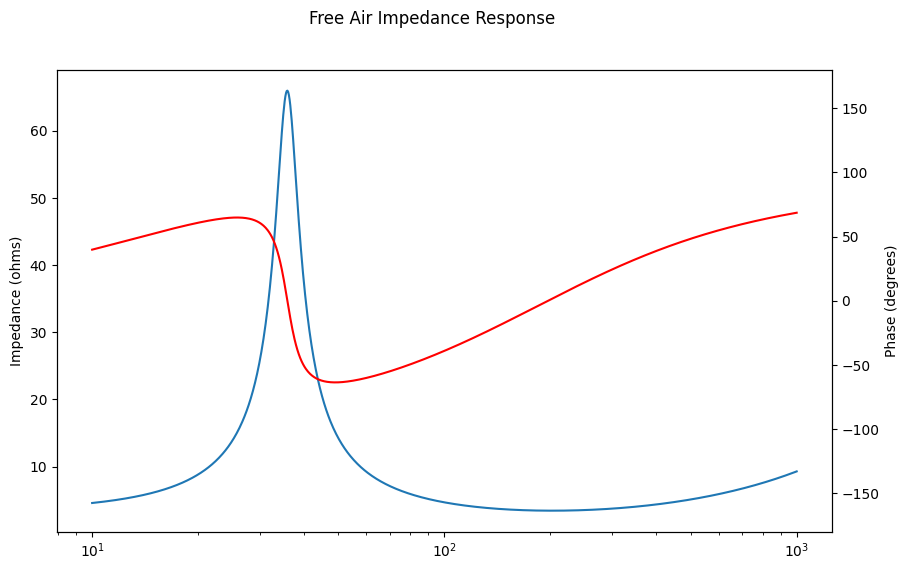

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (10,6))

ax.semilogx(freqs, np.abs(fa_response.input_impedance))
ax.set_ylabel('Impedance (ohms)')
axx = ax.twinx()
axx.semilogx(freqs, np.angle(fa_response.input_impedance, deg = True), color='red')
axx.set_ylim([-180,180])
axx.set_ylabel('Phase (degrees)')
fig.suptitle('Free Air Impedance Response')

In [7]:
fa_chars.resonance_frequency
fa_chars.effective_compliance

0.0005

In [24]:
from src.enclosure import SealedBox

box = SealedBox(volume=3.85e-3)

closed_system = LoudspeakerSystem(driver=driver, enclosure=box)
closed_response = closed_system.solve(f = freqs, voltage = 60)
closed_chars = closed_system.characteristics()

Text(0.5, 0.98, 'Closed Box Impedance Response')

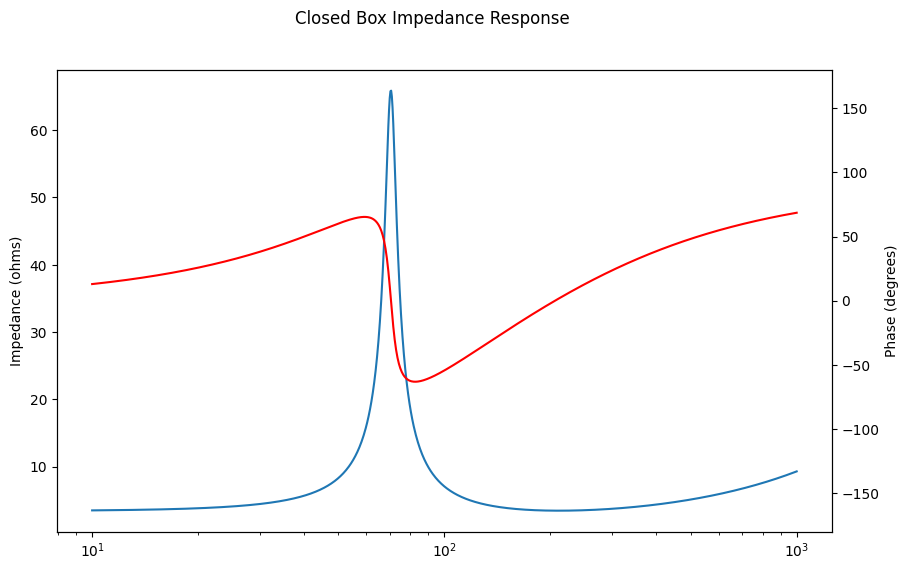

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (10,6))

ax.semilogx(freqs, np.abs(closed_response.input_impedance))
ax.set_ylabel('Impedance (ohms)')
axx = ax.twinx()
axx.semilogx(freqs, np.angle(closed_response.input_impedance, deg = True), color='red')
axx.set_ylim([-180,180])
axx.set_ylabel('Phase (degrees)')
fig.suptitle('Closed Box Impedance Response')

In [26]:
closed_chars.resonance_frequency, closed_chars.effective_compliance

(np.float64(70.27419626257847), np.float64(0.00012903712021883687))

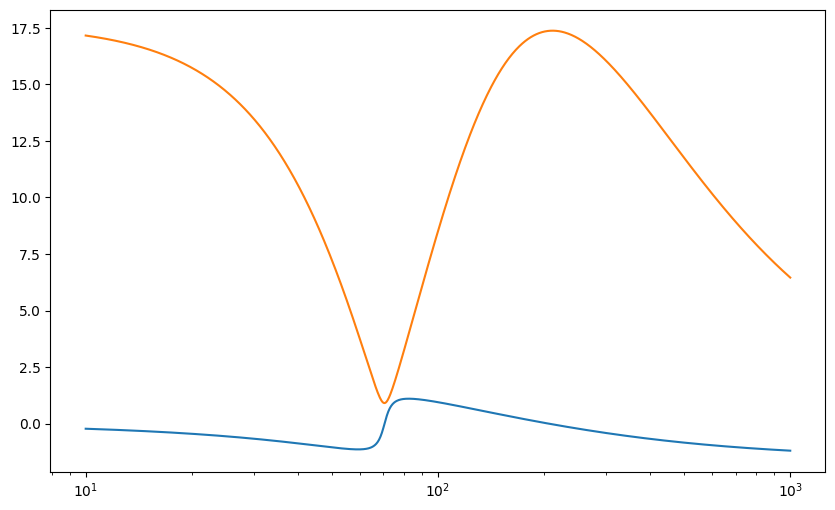

In [33]:
import matplotlib.pyplot as plt

Xmax = 6e-3 # mm

fig, ax = plt.subplots(figsize = (10,6))

ax.semilogx(freqs, np.angle(closed_response.current))
ax.semilogx(freqs, np.abs(closed_response.current))
# ax.axhline(Xmax)
# ax.set_ylabel('Impedance (ohms)')
# axx = ax.twinx()
# axx.semilogx(freqs, np.angle(closed_response.input_impedance, deg = True), color='red')
# axx.set_ylim([-180,180])
# axx.set_ylabel('Phase (degrees)')
# fig.suptitle('Closed Box Impedance Response')